# Fine-Tuning IndoBERT ABSA Hotel Santika - Dataset V3 Final Audited (Kaggle Ready)

Notebook ini adalah lanjutan dari `finetune2.ipynb`, tetapi input datanya diarahkan ke hasil audit label dan split terbaru:

- Dataset sumber: `dataset_absa_labeled_v3_final_audited.csv`
- Split sumber: `train.csv`, `validation.csv`, `test.csv` dari notebook `data_splitting_absa_kaggle_ready_v3.ipynb`
- Rasio split: 80/10/10 dengan multi-label stratification per aspek-label

Tujuan notebook ini adalah fine-tuning ulang model ABSA setelah audit label, lalu membandingkan performa model final terhadap model sebelumnya menggunakan metrik yang lebih relevan untuk ABSA:

- `macro_f1`
- `weighted_f1`
- `non_none_macro_f1`
- `aspect_detection_f1`
- `false_aspect_rate`
- classification report dan confusion matrix per aspek

Catatan penting:

- Validation set digunakan untuk memilih checkpoint/model terbaik.
- Test set hanya digunakan untuk evaluasi akhir.
- Notebook ini tidak membuat split ulang agar tidak terjadi data leakage atau perubahan basis evaluasi.


## 1. Setup

In [14]:
import sys, subprocess
def pipi(p): subprocess.run([sys.executable,'-m','pip','install','-q',*p])
# PENTING: jangan menurunkan numpy. Kaggle berbasis numpy 2.x; transformers==4.44 (butuh numpy<2)
# akan menurunkan numpy -> error 'numpy.dtype size changed' saat import pandas.
# sentencepiece TETAP dipasang (dibutuhkan tokenizer indobert-lite). datasets/evaluate tidak dipakai.
pipi(['transformers>=4.46,<5','accelerate>=0.34','sentencepiece'])
import numpy, transformers
print('done. numpy', numpy.__version__, '| transformers', transformers.__version__)
print('Jika numpy < 2.0 di sini: menu Run -> Factory reset, lalu jalankan ulang dari sel ini.')

done. numpy 2.4.6 | transformers 4.57.6
Jika numpy < 2.0 di sini: menu Run -> Factory reset, lalu jalankan ulang dari sel ini.


In [15]:

import os, json, random, gc, itertools, time, traceback
from pathlib import Path

import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, BertTokenizer, AutoModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix


def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print(torch.cuda.get_device_name(0))


Device: cuda
Tesla T4


## 2. Load Data Split V3 Final Audited

Upload hasil split v3 ke Kaggle Input. Notebook ini akan mencari file berikut secara otomatis:

- `train.csv`
- `validation.csv`
- `test.csv`
- opsional: `split_manifest.json`

Pastikan file tersebut berasal dari notebook `data_splitting_absa_kaggle_ready_v3.ipynb`, bukan split lama.


In [16]:
ASPECTS = ['Lokasi', 'Kenyamanan', 'Pelayanan', 'Kebersihan', 'Harga', 'Makanan', 'Fasilitas']
LABEL2ID = {'none': 0, 'positif': 1, 'negatif': 2, 'netral': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 4
LABEL_NAMES = ['none', 'positif', 'negatif', 'netral']

DATASET_VERSION = 'v3_final_audited'
SPLIT_VERSION = 'v3_multilabel_stratified_80_10_10'
EXPECTED_SPLIT_ROWS = {'train': 11797, 'validation': 1475, 'test': 1475}

KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_WORKING = Path('/kaggle/working')

# Path eksplisit untuk nama Kaggle dataset yang direkomendasikan.
# Jika nama dataset berbeda, resolver di bawah akan mencari secara deterministic.
SPLIT_DIR_CANDIDATES = [
    KAGGLE_INPUT / 'absa-santika-split-v3' / 'absa_santika_split_v3',
    KAGGLE_INPUT / 'absa-santika-split-v3' / 'absa-santika-split-v3',
    KAGGLE_INPUT / 'absa-santika-split-v3',
    KAGGLE_INPUT / 'absa-santika-v3-split' / 'absa_santika_split_v3',
    KAGGLE_INPUT / 'absa-santika-v3-split',
]

LOCAL_SPLIT_DIR_CANDIDATES = [
    Path.cwd() / 'absa_santika_split_v3',
    Path.cwd() / 'absa-santika-split-v3',
    Path.cwd().parent / 'absa_santika_split_v3',
    Path.cwd().parent / 'absa-santika-split-v3',
]


def resolve_input_path(filename, preferred_keywords=('v3', 'split'), required=True):
    for directory in SPLIT_DIR_CANDIDATES + LOCAL_SPLIT_DIR_CANDIDATES:
        path = directory / filename
        if path.exists():
            return path

    candidates = []
    if KAGGLE_INPUT.exists():
        candidates = sorted(KAGGLE_INPUT.rglob(filename), key=lambda x: str(x).lower())
    else:
        search_roots = [Path.cwd(), Path.cwd().parent]
        for root in search_roots:
            if root.exists():
                candidates.extend(root.rglob(filename))
        candidates = sorted(set(candidates), key=lambda x: str(x).lower())

    def score(path):
        low = str(path).lower()
        return sum(keyword.lower() in low for keyword in preferred_keywords)

    candidates = sorted(candidates, key=lambda x: (-score(x), str(x).lower()))
    if candidates:
        picked = candidates[0]
        print(f'[WARN] Menggunakan kandidat path: {picked}')
        return picked

    if required:
        raise FileNotFoundError(
            f'Tidak menemukan {filename}. Upload hasil split v3 ke Kaggle Input. '
            f'File yang dicari: train.csv, validation.csv, test.csv.'
        )
    return None


def load_csv(path):
    return pd.read_csv(path, encoding='utf-8-sig', dtype=str).fillna('')


def nlab(v):
    v = str(v).strip().lower()
    return v if v in LABEL2ID else 'none'


train_path = resolve_input_path('train.csv', preferred_keywords=('v3', 'split', 'train'), required=True)
val_path = resolve_input_path('validation.csv', preferred_keywords=('v3', 'split', 'validation'), required=True)
test_path = resolve_input_path('test.csv', preferred_keywords=('v3', 'split', 'test'), required=True)
manifest_path = resolve_input_path('split_manifest.json', preferred_keywords=('v3', 'split'), required=False)

train_df = load_csv(train_path)
val_df = load_csv(val_path)
test_df = load_csv(test_path)
no_aspect_df = pd.DataFrame(columns=train_df.columns)

split_manifest = None
if manifest_path is not None:
    with open(manifest_path, 'r', encoding='utf-8') as f:
        split_manifest = json.load(f)

print('Loaded V3 split:')
print('  train     :', train_path)
print('  validation:', val_path)
print('  test      :', test_path)
print('  manifest  :', manifest_path if manifest_path else 'not found / optional')

TEXT_COL = 'Text_Review' if 'Text_Review' in train_df.columns else 'text_review'
ID_COL = 'ID_Review' if 'ID_Review' in train_df.columns else ('review_id' if 'review_id' in train_df.columns else None)
REQUIRED_COLS = [TEXT_COL] + ASPECTS


def validate_frame(df, name):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f'Kolom hilang di {name}: {missing}. Kolom tersedia: {list(df.columns)}')
    if len(df) == 0:
        raise ValueError(f'{name} kosong.')
    empty_text = df[TEXT_COL].astype(str).str.strip().eq('').sum()
    if empty_text:
        raise ValueError(f'{name} memiliki {empty_text} Text_Review kosong.')
    invalid = {}
    for aspect in ASPECTS:
        values = df[aspect].astype(str).str.strip().str.lower().replace({'': 'none', 'nan': 'none', '-': 'none'})
        bad = sorted(set(values) - set(LABEL2ID.keys()))
        if bad:
            invalid[aspect] = bad[:10]
        df[aspect] = values
    if invalid:
        raise ValueError(f'Label invalid di {name}: {invalid}')


validate_frame(train_df, 'train')
validate_frame(val_df, 'validation')
validate_frame(test_df, 'test')

if ID_COL is not None:
    for frame in [train_df, val_df, test_df]:
        frame[ID_COL] = frame[ID_COL].astype(str)
    train_ids, val_ids, test_ids = set(train_df[ID_COL]), set(val_df[ID_COL]), set(test_df[ID_COL])
    overlaps = {
        'train_val': len(train_ids & val_ids),
        'train_test': len(train_ids & test_ids),
        'val_test': len(val_ids & test_ids),
    }
    print('Split overlap:', overlaps)
    if any(overlaps.values()):
        raise ValueError(f'Data leakage antar split terdeteksi: {overlaps}')

actual_rows = {'train': len(train_df), 'validation': len(val_df), 'test': len(test_df)}
print('Actual rows:', actual_rows)
if actual_rows != EXPECTED_SPLIT_ROWS:
    print('[WARN] Jumlah row berbeda dari split v3 lokal yang diharapkan:', EXPECTED_SPLIT_ROWS)

if split_manifest:
    print('Split manifest method:', split_manifest.get('method'))
    print('Split manifest max diff:', split_manifest.get('max_abs_pct_diff_aspect_label'))

_total_rows = len(train_df) + len(val_df) + len(test_df)
display(pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'percentage': [len(train_df)/_total_rows, len(val_df)/_total_rows, len(test_df)/_total_rows],
}))


[WARN] Path eksplisit tidak ditemukan: /kaggle/input/absa-santika-split/absa-santika-split/train.csv
[WARN] Menggunakan kandidat deterministic: /kaggle/input/datasets/korneliusvincent/absa-santika-split/absa-santika-split/train.csv
[WARN] Path eksplisit tidak ditemukan: /kaggle/input/absa-santika-split/absa-santika-split/validation.csv
[WARN] Menggunakan kandidat deterministic: /kaggle/input/datasets/korneliusvincent/absa-santika-split/absa-santika-split/validation.csv
[WARN] Path eksplisit tidak ditemukan: /kaggle/input/absa-santika-split/absa-santika-split/test.csv
[WARN] Menggunakan kandidat deterministic: /kaggle/input/datasets/korneliusvincent/absa-santika-split/absa-santika-split/test.csv
[WARN] Path eksplisit tidak ditemukan: /kaggle/input/absa-santika-split/absa-santika-split/no_aspect.csv
[WARN] Menggunakan kandidat deterministic: /kaggle/input/datasets/korneliusvincent/absa-santika-split/absa-santika-split/no_aspect.csv
[WARN] Path eksplisit tidak ditemukan: /kaggle/input/abs

,split,rows
0,train,10706
1,validation,1267
2,test,1309
3,no_aspect,1465


In [17]:

def targets(df):
    Y = np.zeros((len(df), len(ASPECTS)), dtype=np.int64)
    for i, aspect in enumerate(ASPECTS):
        Y[:, i] = df[aspect].map(nlab).map(LABEL2ID).astype(np.int64).values
    return Y


y_train, y_val, y_test = targets(train_df), targets(val_df), targets(test_df)
y_no_aspect = targets(no_aspect_df) if len(no_aspect_df) else np.zeros((0, len(ASPECTS)), dtype=np.int64)

# Class weighting memakai sqrt inverse-frequency + clipping agar kelas sangat kecil
# tidak memberi loss terlalu ekstrem. Ini lebih stabil daripada inverse penuh.
CLASS_WEIGHT_MODE = 'sqrt_capped'
CLASS_WEIGHT_MAX = 4.0
CLASS_WEIGHT_MIN = 0.25


def cls_weights(y, mode=CLASS_WEIGHT_MODE):
    W = np.ones((len(ASPECTS), NUM_CLASSES), dtype=np.float32)
    for i in range(len(ASPECTS)):
        vals, cnts = np.unique(y[:, i], return_counts=True)
        freq = np.zeros(NUM_CLASSES, dtype=np.float32)
        freq[vals] = cnts
        freq[freq == 0] = 1.0
        inv = freq.sum() / (NUM_CLASSES * freq)
        if mode == 'sqrt_capped':
            w = np.sqrt(inv)
            w = np.clip(w, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)
            w = w / w.mean()
        elif mode == 'inverse_capped':
            w = np.clip(inv, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)
            w = w / w.mean()
        else:
            w = np.ones(NUM_CLASSES, dtype=np.float32)
        W[i] = w
    return torch.tensor(W, dtype=torch.float32).to(DEVICE)


CLASS_W = cls_weights(y_train)
class_weight_df = pd.DataFrame(
    CLASS_W.detach().cpu().numpy(),
    index=ASPECTS,
    columns=LABEL_NAMES,
).round(3)
print('Class weight mode:', CLASS_WEIGHT_MODE)
display(class_weight_df)

# Ringkas distribusi label per split untuk audit cepat.
def label_distribution_df(name, y):
    rows = []
    for i, aspect in enumerate(ASPECTS):
        counts = pd.Series(y[:, i]).map(ID2LABEL).value_counts().reindex(LABEL_NAMES, fill_value=0)
        rows.append({'split': name, 'aspect': aspect, **counts.to_dict()})
    return pd.DataFrame(rows)

dist_df = pd.concat([
    label_distribution_df('train', y_train),
    label_distribution_df('validation', y_val),
    label_distribution_df('test', y_test),
], ignore_index=True)
display(dist_df)


Class weight mode: sqrt_capped


,none,positif,negatif,netral
Lokasi,0.269,0.397,1.582,1.752
Kenyamanan,0.398,0.560,0.879,2.163
Pelayanan,0.418,0.505,1.221,1.856
Kebersihan,0.302,0.493,1.198,2.008
Harga,0.196,0.884,1.412,1.508
Makanan,0.430,0.633,1.303,1.634
Fasilitas,0.384,1.022,0.987,1.606


,split,aspect,none,positif,negatif,netral
0,train,Lokasi,7090,3263,205,148
1,train,Kenyamanan,6132,3107,1259,208
2,train,Pelayanan,5781,3955,677,293
3,train,Kebersihan,7402,2775,470,59
4,train,Harga,9914,487,191,114
5,train,Makanan,6523,3018,712,453
6,train,Fasilitas,7928,1121,1203,454
7,validation,Lokasi,814,408,26,19
8,validation,Kenyamanan,694,389,158,26
9,validation,Pelayanan,650,495,85,37


## 3. Dataset & Model (multi-head) + freeze option

In [18]:
class DS(Dataset):
    def __init__(self,texts,Y,tok,ml): self.t=list(texts); self.Y=Y; self.tok=tok; self.ml=ml
    def __len__(self): return len(self.t)
    def __getitem__(self,i):
        e=self.tok(self.t[i],truncation=True,max_length=self.ml,padding='max_length',return_tensors='pt')
        it={k:v.squeeze(0) for k,v in e.items()}; it['labels']=torch.tensor(self.Y[i]); return it

class MultiHead(nn.Module):
    def __init__(self,name,na,nc,dropout=0.1,freeze=0):
        super().__init__(); self.enc=AutoModel.from_pretrained(name)
        h=self.enc.config.hidden_size; self.drop=nn.Dropout(dropout)
        self.heads=nn.ModuleList([nn.Linear(h,nc) for _ in range(na)])
        if freeze>0:
            for p in self.enc.embeddings.parameters(): p.requires_grad=False
            layers=getattr(self.enc.encoder,'layer',[])
            for l in layers[:freeze]:
                for p in l.parameters(): p.requires_grad=False
    def forward(self,input_ids,attention_mask,token_type_ids=None):
        o=self.enc(input_ids=input_ids,attention_mask=attention_mask)
        cls=self.drop(o.last_hidden_state[:,0])
        return torch.stack([hd(cls) for hd in self.heads],dim=1)

## 4. Training + Early Stopping + evaluasi

In [19]:

def make_loss(cw, smoothing):
    if cw:
        outs = [nn.CrossEntropyLoss(weight=CLASS_W[i], label_smoothing=smoothing) for i in range(len(ASPECTS))]
    else:
        outs = [nn.CrossEntropyLoss(label_smoothing=smoothing) for _ in range(len(ASPECTS))]

    def fn(logits, labels):
        return sum(outs[i](logits[:, i, :], labels[:, i]) for i in range(len(ASPECTS))) / len(ASPECTS)
    return fn


def aspect_metrics(y_true, y_pred, aspect_idx):
    yt = y_true[:, aspect_idx]
    yp = y_pred[:, aspect_idx]
    present_mask = yt != LABEL2ID['none']
    true_none_mask = yt == LABEL2ID['none']

    macro_f1 = f1_score(yt, yp, labels=[0, 1, 2, 3], average='macro', zero_division=0)
    weighted_f1 = f1_score(yt, yp, labels=[0, 1, 2, 3], average='weighted', zero_division=0)
    acc = accuracy_score(yt, yp)
    non_none_macro_f1 = f1_score(yt, yp, labels=[1, 2, 3], average='macro', zero_division=0)
    aspect_detection_f1 = f1_score((yt != 0).astype(int), (yp != 0).astype(int), zero_division=0)
    false_aspect_rate = float((yp[true_none_mask] != 0).mean()) if true_none_mask.any() else 0.0
    sentiment_macro_f1_present = (
        f1_score(yt[present_mask], yp[present_mask], labels=[1, 2, 3], average='macro', zero_division=0)
        if present_mask.any() else 0.0
    )
    return {
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'acc': float(acc),
        'non_none_macro_f1': float(non_none_macro_f1),
        'aspect_detection_f1': float(aspect_detection_f1),
        'false_aspect_rate': float(false_aspect_rate),
        'sentiment_macro_f1_present': float(sentiment_macro_f1_present),
    }


@torch.no_grad()
def evaluate(model, loader, ret=False):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        labels = batch.pop('labels').to(DEVICE)
        inputs = {k: v.to(DEVICE) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'token_type_ids']}
        logits_all.append(model(**inputs).cpu())
        labels_all.append(labels.cpu())

    if not logits_all:
        empty = {'macro_f1': 0.0, 'weighted_f1': 0.0, 'acc': 0.0, 'non_none_macro_f1': 0.0,
                 'aspect_detection_f1': 0.0, 'false_aspect_rate': 0.0,
                 'sentiment_macro_f1_present': 0.0, 'per_aspect': {}}
        return (empty, np.empty((0, len(ASPECTS))), np.empty((0, len(ASPECTS)))) if ret else empty

    L = torch.cat(logits_all)
    Y = torch.cat(labels_all).numpy()
    P = L.argmax(-1).numpy()

    per = {aspect: aspect_metrics(Y, P, i) for i, aspect in enumerate(ASPECTS)}
    r = {
        'macro_f1': float(np.mean([per[a]['macro_f1'] for a in ASPECTS])),
        'weighted_f1': float(np.mean([per[a]['weighted_f1'] for a in ASPECTS])),
        'acc': float(np.mean([per[a]['acc'] for a in ASPECTS])),
        'non_none_macro_f1': float(np.mean([per[a]['non_none_macro_f1'] for a in ASPECTS])),
        'aspect_detection_f1': float(np.mean([per[a]['aspect_detection_f1'] for a in ASPECTS])),
        'false_aspect_rate': float(np.mean([per[a]['false_aspect_rate'] for a in ASPECTS])),
        'sentiment_macro_f1_present': float(np.mean([per[a]['sentiment_macro_f1_present'] for a in ASPECTS])),
        'per_aspect': per,
    }
    return (r, P, Y) if ret else r


In [20]:
def build_opt(model,cfg):
    if cfg.get('optimizer','adamw')=='adafactor':
        from transformers.optimization import Adafactor
        return Adafactor(model.parameters(),lr=cfg['lr'],scale_parameter=False,relative_step=False,warmup_init=False)
    return AdamW(model.parameters(),lr=cfg['lr'],weight_decay=cfg.get('weight_decay',0.01))

def build_sched(opt,cfg,total):
    w=int(cfg.get('warmup_ratio',0.1)*total)
    if cfg.get('scheduler','linear')=='cosine':
        return get_cosine_schedule_with_warmup(opt,w,total)
    return get_linear_schedule_with_warmup(opt,w,total)

def train_cfg(cfg, verbose=True):
    set_seed(cfg.get('seed',42))
    # indobert-lite = arsitektur ALBERT tapi vocab WordPiece (vocab.txt),
    # jadi AutoTokenizer keliru memilih AlbertTokenizer (cari SentencePiece) -> 'not a string'.
    # Pakai BertTokenizer untuk model lite, AutoTokenizer untuk lainnya.
    name=cfg['model_name']
    tok=(BertTokenizer if 'lite' in name.lower() else AutoTokenizer).from_pretrained(name)
    trL=DataLoader(DS(train_df[TEXT_COL].tolist(),y_train,tok,cfg['max_len']),batch_size=cfg['batch_size'],shuffle=True)
    vaL=DataLoader(DS(val_df[TEXT_COL].tolist(),y_val,tok,cfg['max_len']),batch_size=cfg['batch_size'])
    model=MultiHead(cfg['model_name'],len(ASPECTS),NUM_CLASSES,cfg.get('dropout',0.1),cfg.get('freeze_layers',0)).to(DEVICE)
    loss_fn=make_loss(cfg.get('class_weight',False),cfg.get('label_smoothing',0.0))
    opt=build_opt(model,cfg); total=len(trL)*cfg['max_epochs']; sched=build_sched(opt,cfg,total)
    best=-1; best_state=None; bad=0; patience=cfg.get('patience',2); hist=[]
    for ep in range(cfg['max_epochs']):
        model.train()
        for b in trL:
            lb=b.pop('labels').to(DEVICE); b={k:v.to(DEVICE) for k,v in b.items() if k in ['input_ids','attention_mask','token_type_ids']}
            loss=loss_fn(model(**b),lb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); sched.step(); opt.zero_grad()
        r=evaluate(model,vaL); hist.append(r['macro_f1'])
        if verbose: print(f"   ep{ep+1}/{cfg['max_epochs']} valF1={r['macro_f1']:.4f}")
        if r['macro_f1']>best+1e-4:
            best=r['macro_f1']; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=patience:
                if verbose: print(f'   early stop @ epoch {ep+1}')
                break
    if best_state: model.load_state_dict(best_state)
    return model,tok,best,hist,(ep+1)

## 5. Ruang pencarian (Grid & Random)

Atur `SEARCH_MODE`:
- `'curated'` : daftar konfigurasi pilihan (cepat, direkomendasikan untuk mulai).
- `'random'`  : sampel acak dari ruang besar sebanyak `N_RANDOM` (Bergstra & Bengio 2012).
- `'grid'`    : full cartesian dari `GRID` (HATI-HATI: bisa sangat banyak & lama).

In [21]:
P1='indobenchmark/indobert-base-p1'
LITE='indobenchmark/indobert-lite-base-p1'
LEM='indolem/indobert-base-uncased'

# Fine-tune v3 difokuskan pada konfigurasi yang masuk akal untuk dataset audit final.
# max_len 160 dan 192 ditambahkan karena audit menemukan banyak review panjang/multi-aspek.
SPACE = dict(
    model_name=[P1, LEM, LITE],
    lr=[1e-5,2e-5,3e-5],
    batch_size=[8,16,32],
    max_epochs=[6,8,10],
    max_len=[128,160,192],
    warmup_ratio=[0.06,0.1],
    weight_decay=[0.01,0.1],
    dropout=[0.1,0.2,0.3],
    scheduler=['linear','cosine'],
    optimizer=['adamw'],
    label_smoothing=[0.0,0.05,0.1],
    freeze_layers=[0,6],
    class_weight=[False,True],
    seed=[42,7,123],
)

# Curated experiments: cukup kuat untuk pembandingan tanpa terlalu boros waktu Kaggle.
CURATED=[
    dict(name='v3_p1_base_128',       model_name=P1, lr=2e-5, batch_size=16, max_epochs=8,  max_len=128, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.1, scheduler='linear', optimizer='adamw', label_smoothing=0.0,  freeze_layers=0, class_weight=False, patience=2, seed=42),
    dict(name='v3_p1_cw_128',         model_name=P1, lr=3e-5, batch_size=16, max_epochs=10, max_len=128, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.2, scheduler='linear', optimizer='adamw', label_smoothing=0.05, freeze_layers=0, class_weight=True,  patience=3, seed=42),
    dict(name='v3_p1_cw_160',         model_name=P1, lr=3e-5, batch_size=16, max_epochs=10, max_len=160, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.2, scheduler='linear', optimizer='adamw', label_smoothing=0.05, freeze_layers=0, class_weight=True,  patience=3, seed=42),
    dict(name='v3_p1_cw_192_bs8',     model_name=P1, lr=2e-5, batch_size=8,  max_epochs=10, max_len=192, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.2, scheduler='cosine', optimizer='adamw', label_smoothing=0.05, freeze_layers=0, class_weight=True,  patience=3, seed=42),
    dict(name='v3_p1_no_cw_160',      model_name=P1, lr=2e-5, batch_size=16, max_epochs=8,  max_len=160, warmup_ratio=0.06, weight_decay=0.01, dropout=0.1, scheduler='cosine', optimizer='adamw', label_smoothing=0.0,  freeze_layers=0, class_weight=False, patience=2, seed=42),
    dict(name='v3_p1_freeze6_160',    model_name=P1, lr=3e-5, batch_size=32, max_epochs=10, max_len=160, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.1, scheduler='linear', optimizer='adamw', label_smoothing=0.0,  freeze_layers=6, class_weight=False, patience=3, seed=42),
    dict(name='v3_lem_cw_160',        model_name=LEM, lr=3e-5, batch_size=16, max_epochs=10, max_len=160, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.2, scheduler='cosine', optimizer='adamw', label_smoothing=0.05, freeze_layers=0, class_weight=True,  patience=3, seed=42),
    dict(name='v3_lite_fast_160',     model_name=LITE,lr=3e-5, batch_size=32, max_epochs=10, max_len=160, warmup_ratio=0.1,  weight_decay=0.01, dropout=0.1, scheduler='linear', optimizer='adamw', label_smoothing=0.0,  freeze_layers=0, class_weight=False, patience=3, seed=42),
]


In [22]:
SEARCH_MODE='curated'   # direkomendasikan untuk run utama; opsi lain: 'random' | 'grid'
N_RANDOM=8              # dipakai jika SEARCH_MODE='random'

def sample_random(n, seed=42):
    rng=random.Random(seed); out=[]
    for j in range(n):
        cfg={k:rng.choice(v) for k,v in SPACE.items()}
        cfg['patience']=2; cfg['name']=f'rand_{j+1}'
        out.append(cfg)
    return out

def build_grid(keys):
    # cartesian hanya untuk subset keys yang dipilih (selain pakai default)
    base=dict(model_name=P1,max_len=128,warmup_ratio=0.1,weight_decay=0.01,dropout=0.1,
              scheduler='linear',optimizer='adamw',label_smoothing=0.0,freeze_layers=0,
              class_weight=False,seed=42,patience=2)
    vals=[SPACE[k] for k in keys]; out=[]
    for combo in itertools.product(*vals):
        c=dict(base); c.update(dict(zip(keys,combo)))
        c['name']='grid_'+'_'.join(f'{k}{c[k]}' for k in keys)
        out.append(c)
    return out

if SEARCH_MODE=='curated':
    EXPERIMENTS=CURATED
elif SEARCH_MODE=='random':
    EXPERIMENTS=sample_random(N_RANDOM)
else:
    # contoh grid 3-variabel: lr x batch_size x max_epochs (4*3*4 = 48 run!)
    EXPERIMENTS=build_grid(['lr','batch_size','max_epochs'])
print('Total eksperimen:', len(EXPERIMENTS))


Total eksperimen: 10


## 6. Jalankan eksperimen

In [23]:

def is_oom_error(err):
    msg = str(err).lower()
    return any(token in msg for token in [
        'out of memory',
        'cuda error: out of memory',
        'cublas_status_alloc_failed',
        'cuda out of memory',
    ])


results = []
best = None
t0 = time.time()
for cfg in EXPERIMENTS:
    print('=' * 64)
    print('RUN:', cfg['name'])
    try:
        model, tok, vf1, hist, ran_ep = train_cfg(cfg)
    except RuntimeError as e:
        if is_oom_error(e):
            print('  SKIP OOM:', str(e)[:180])
            torch.cuda.empty_cache(); gc.collect()
            continue
        print(traceback.format_exc())
        raise

    row = {k: cfg.get(k) for k in [
        'name', 'model_name', 'lr', 'batch_size', 'max_epochs', 'max_len',
        'warmup_ratio', 'weight_decay', 'dropout', 'scheduler', 'optimizer',
        'label_smoothing', 'freeze_layers', 'class_weight', 'seed'
    ]}
    row['epochs_ran'] = ran_ep
    row['val_macro_f1'] = vf1
    results.append(row)
    print(f'  >> val_macroF1={vf1:.4f} (ran {ran_ep} epoch)')

    if best is None or vf1 > best['vf1']:
        if best is not None:
            del best['model']
            gc.collect(); torch.cuda.empty_cache()
        best = {'cfg': cfg, 'vf1': vf1, 'model': model, 'tok': tok}
    else:
        del model
        gc.collect(); torch.cuda.empty_cache()

print(f'Total waktu: {(time.time() - t0) / 60:.1f} menit')
if not results or best is None:
    raise RuntimeError('Tidak ada eksperimen yang berhasil. Cek path data, koneksi model Hugging Face, atau konfigurasi GPU.')
res_df = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
res_df


RUN: c1_p1_base
   ep1/8 valF1=0.6138
   ep2/8 valF1=0.6484
   ep3/8 valF1=0.6926
   ep4/8 valF1=0.6952
   ep5/8 valF1=0.6964
   ep6/8 valF1=0.7112
   ep7/8 valF1=0.7049
   ep8/8 valF1=0.7072
   early stop @ epoch 8
  >> val_macroF1=0.7112 (ran 8 epoch)
RUN: c2_p1_lr3
   ep1/8 valF1=0.6263
   ep2/8 valF1=0.6502
   ep3/8 valF1=0.6881
   ep4/8 valF1=0.7049
   ep5/8 valF1=0.7096
   ep6/8 valF1=0.7178
   ep7/8 valF1=0.7168
   ep8/8 valF1=0.7207
  >> val_macroF1=0.7207 (ran 8 epoch)
RUN: c3_p1_bs32_cos
   ep1/10 valF1=0.6079
   ep2/10 valF1=0.6394
   ep3/10 valF1=0.6858
   ep4/10 valF1=0.6921
   ep5/10 valF1=0.7018
   ep6/10 valF1=0.7041
   ep7/10 valF1=0.7155
   ep8/10 valF1=0.7105
   ep9/10 valF1=0.7087
   ep10/10 valF1=0.7099
   early stop @ epoch 10
  >> val_macroF1=0.7155 (ran 10 epoch)
RUN: c4_p1_cw_ls
   ep1/10 valF1=0.6419
   ep2/10 valF1=0.7148
   ep3/10 valF1=0.7134
   ep4/10 valF1=0.7276
   ep5/10 valF1=0.7312
   ep6/10 valF1=0.7330
   ep7/10 valF1=0.7285
   ep8/10 valF1=0.7352
 

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


pytorch_model.bin:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

   ep1/10 valF1=0.5001
   ep2/10 valF1=0.5795
   ep3/10 valF1=0.6102
   ep4/10 valF1=0.6207
   ep5/10 valF1=0.6655
   ep6/10 valF1=0.6624
   ep7/10 valF1=0.6652
   ep8/10 valF1=0.6682
   ep9/10 valF1=0.6689
   ep10/10 valF1=0.6738
  >> val_macroF1=0.6738 (ran 10 epoch)
RUN: c10_p1_adafactor
   ep1/8 valF1=0.6130
   ep2/8 valF1=0.6609
   ep3/8 valF1=0.6796
   ep4/8 valF1=0.6919
   ep5/8 valF1=0.6908
   ep6/8 valF1=0.7145
   ep7/8 valF1=0.7143
   ep8/8 valF1=0.7158
  >> val_macroF1=0.7158 (ran 8 epoch)
Total waktu: 370.1 menit


,name,model_name,lr,batch_size,max_epochs,max_len,warmup_ratio,weight_decay,dropout,scheduler,optimizer,label_smoothing,freeze_layers,class_weight,seed,epochs_ran,val_macro_f1
0,c4_p1_cw_ls,indobenchmark/indobert-base-p1,0.00003,16,10,128,0.10,0.01,0.2,linear,adamw,0.1,0,True,None,10,0.736614
1,c8_lem_cw,indolem/indobert-base-uncased,0.00003,16,10,128,0.10,0.01,0.2,cosine,adamw,0.1,0,True,None,10,0.720932
2,c2_p1_lr3,indobenchmark/indobert-base-p1,0.00003,16,8,128,0.10,0.01,0.1,linear,adamw,0.0,0,False,None,8,0.720714
3,c10_p1_adafactor,indobenchmark/indobert-base-p1,0.00003,16,8,128,0.10,0.00,0.1,linear,adafactor,0.0,0,False,None,8,0.715790
4,c3_p1_bs32_cos,indobenchmark/indobert-base-p1,0.00003,32,10,128,0.06,0.01,0.1,cosine,adamw,0.0,0,False,None,10,0.715486
5,c1_p1_base,indobenchmark/indobert-base-p1,0.00002,16,8,128,0.10,0.01,0.1,linear,adamw,0.0,0,False,None,8,0.711226
6,c5_p1_bs8_lr1,indobenchmark/indobert-base-p1,0.00001,8,8,160,0.10,0.10,0.1,cosine,adamw,0.0,0,False,None,8,0.699914
7,c6_p1_freeze6,indobenchmark/indobert-base-p1,0.00005,32,10,128,0.10,0.01,0.1,linear,adamw,0.0,6,False,None,10,0.698455
8,c7_lem_base,indolem/indobert-base-uncased,0.00003,16,8,128,0.10,0.01,0.1,linear,adamw,0.0,0,False,None,7,0.695799
9,c9_lite_fast,indobenchmark/indobert-lite-base-p1,0.00003,32,10,128,0.10,0.01,0.1,linear,adamw,0.0,0,False,None,10,0.673761


## 7. Evaluasi model terbaik di TEST

In [24]:

if best is None:
    raise RuntimeError('Belum ada model terbaik. Jalankan cell eksperimen terlebih dahulu.')

bc = best['cfg']
bm = best['model']
bt = best['tok']
print('Terbaik:', bc['name'], '| val_macroF1=', round(best['vf1'], 4))

teL = DataLoader(DS(test_df[TEXT_COL].tolist(), y_test, bt, bc['max_len']), batch_size=bc['batch_size'])
tr, P, Y = evaluate(bm, teL, ret=True)
print(
    'TEST | macroF1=', round(tr['macro_f1'], 4),
    '| weightedF1=', round(tr['weighted_f1'], 4),
    '| nonNoneF1=', round(tr['non_none_macro_f1'], 4),
    '| aspectDetectF1=', round(tr['aspect_detection_f1'], 4),
    '| falseAspectRate=', round(tr['false_aspect_rate'], 4),
    '| acc=', round(tr['acc'], 4),
)
for aspect, value in tr['per_aspect'].items():
    print(
        f"  {aspect:12s} macroF1={value['macro_f1']:.4f} "
        f"nonNoneF1={value['non_none_macro_f1']:.4f} "
        f"detectF1={value['aspect_detection_f1']:.4f} "
        f"falseAspect={value['false_aspect_rate']:.4f} "
        f"acc={value['acc']:.4f}"
    )

# Audit no-aspect: mengukur kecenderungan model mengarang aspek pada review umum.
no_aspect_summary = None
if len(no_aspect_df) > 0:
    noL = DataLoader(DS(no_aspect_df[TEXT_COL].tolist(), y_no_aspect, bt, bc['max_len']), batch_size=bc['batch_size'])
    no_tr, noP, noY = evaluate(bm, noL, ret=True)
    no_aspect_summary = {
        'n_rows': int(len(no_aspect_df)),
        'false_aspect_rate_mean': float(no_tr['false_aspect_rate']),
        'per_aspect_false_aspect_rate': {
            aspect: float(no_tr['per_aspect'][aspect]['false_aspect_rate']) for aspect in ASPECTS
        },
    }
    print('\nNO-ASPECT AUDIT')
    print('Rows:', no_aspect_summary['n_rows'])
    print('Mean false aspect rate:', round(no_aspect_summary['false_aspect_rate_mean'], 4))
    for aspect, rate in no_aspect_summary['per_aspect_false_aspect_rate'].items():
        print(f'  {aspect:12s}: {rate:.4f}')
else:
    print('\nNO-ASPECT AUDIT skipped: no_aspect.csv tidak ditemukan / kosong.')


Terbaik: c4_p1_cw_ls | val_macroF1= 0.7366
TEST | macroF1= 0.7418 | weightedF1= 0.9245 | nonNoneF1= 0.6683 | aspectDetectF1= 0.9208 | falseAspectRate= 0.0481 | acc= 0.9239
  Lokasi       macroF1=0.8289 nonNoneF1=0.7819 detectF1=0.9447 falseAspect=0.0397 acc=0.9481
  Kenyamanan   macroF1=0.7116 nonNoneF1=0.6456 detectF1=0.8902 falseAspect=0.1153 acc=0.8648
  Pelayanan    macroF1=0.7548 nonNoneF1=0.6857 detectF1=0.9580 falseAspect=0.0405 acc=0.9244
  Kebersihan   macroF1=0.6997 nonNoneF1=0.6082 detectF1=0.9455 falseAspect=0.0357 acc=0.9542
  Harga        macroF1=0.7135 nonNoneF1=0.6220 detectF1=0.8626 falseAspect=0.0174 acc=0.9656
  Makanan      macroF1=0.7907 nonNoneF1=0.7286 detectF1=0.9659 falseAspect=0.0280 acc=0.9320
  Fasilitas    macroF1=0.6931 nonNoneF1=0.6063 detectF1=0.8785 falseAspect=0.0604 acc=0.8785

NO-ASPECT AUDIT
Rows: 1465
Mean false aspect rate: 0.0527
  Lokasi      : 0.0389
  Kenyamanan  : 0.1229
  Pelayanan   : 0.1010
  Kebersihan  : 0.0239
  Harga       : 0.0218
  M

In [25]:

test_reports = {}
test_confusion_matrices = {}
for i, aspect in enumerate(ASPECTS):
    print('=' * 48)
    print(aspect)
    print(classification_report(
        Y[:, i], P[:, i],
        labels=[0, 1, 2, 3],
        target_names=LABEL_NAMES,
        zero_division=0,
    ))
    test_reports[aspect] = classification_report(
        Y[:, i], P[:, i],
        labels=[0, 1, 2, 3],
        target_names=LABEL_NAMES,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(Y[:, i], P[:, i], labels=[0, 1, 2, 3])
    test_confusion_matrices[aspect] = cm.tolist()
    display(pd.DataFrame(cm, index=[f'true_{x}' for x in LABEL_NAMES], columns=[f'pred_{x}' for x in LABEL_NAMES]))


Lokasi
              precision    recall  f1-score   support

        none       0.98      0.96      0.97       856
     positif       0.91      0.95      0.93       408
     negatif       0.81      0.81      0.81        26
      netral       0.65      0.58      0.61        19

    accuracy                           0.95      1309
   macro avg       0.84      0.82      0.83      1309
weighted avg       0.95      0.95      0.95      1309



,pred_none,pred_positif,pred_negatif,pred_netral
true_none,822,31,3,0
true_positif,13,387,2,6
true_negatif,4,1,21,0
true_netral,0,8,0,11


Kenyamanan
              precision    recall  f1-score   support

        none       0.94      0.88      0.91       737
     positif       0.83      0.87      0.85       389
     negatif       0.76      0.85      0.80       157
      netral       0.26      0.31      0.28        26

    accuracy                           0.86      1309
   macro avg       0.70      0.73      0.71      1309
weighted avg       0.87      0.86      0.87      1309



,pred_none,pred_positif,pred_negatif,pred_netral
true_none,652,59,20,6
true_positif,29,338,10,12
true_negatif,13,5,134,5
true_netral,3,3,12,8


Pelayanan
              precision    recall  f1-score   support

        none       0.97      0.96      0.96       692
     positif       0.92      0.95      0.93       495
     negatif       0.77      0.79      0.78        85
      netral       0.41      0.30      0.34        37

    accuracy                           0.92      1309
   macro avg       0.77      0.75      0.75      1309
weighted avg       0.92      0.92      0.92      1309



...

,pred_none,pred_positif,pred_negatif,pred_netral
true_none,1189,13,5,3
true_positif,6,51,1,3
true_negatif,2,1,19,2
true_netral,0,5,4,5


Makanan
              precision    recall  f1-score   support

        none       0.98      0.97      0.98       785
     positif       0.93      0.94      0.94       378
     negatif       0.77      0.89      0.83        89
      netral       0.47      0.39      0.42        57

    accuracy                           0.93      1309
   macro avg       0.79      0.80      0.79      1309
weighted avg       0.93      0.93      0.93      1309



,pred_none,pred_positif,pred_negatif,pred_netral
true_none,763,10,6,6
true_positif,3,356,5,14
true_negatif,1,4,79,5
true_netral,10,13,12,22


Fasilitas
              precision    recall  f1-score   support

        none       0.97      0.94      0.95       961
     positif       0.75      0.81      0.78       140
     negatif       0.70      0.76      0.73       151
      netral       0.31      0.32      0.31        57

    accuracy                           0.88      1309
   macro avg       0.68      0.71      0.69      1309
weighted avg       0.88      0.88      0.88      1309



,pred_none,pred_positif,pred_negatif,pred_netral
true_none,903,17,29,12
true_positif,6,114,5,15
true_negatif,17,6,115,13
true_netral,7,16,16,18


## 8. Visualisasi perbandingan eksperimen

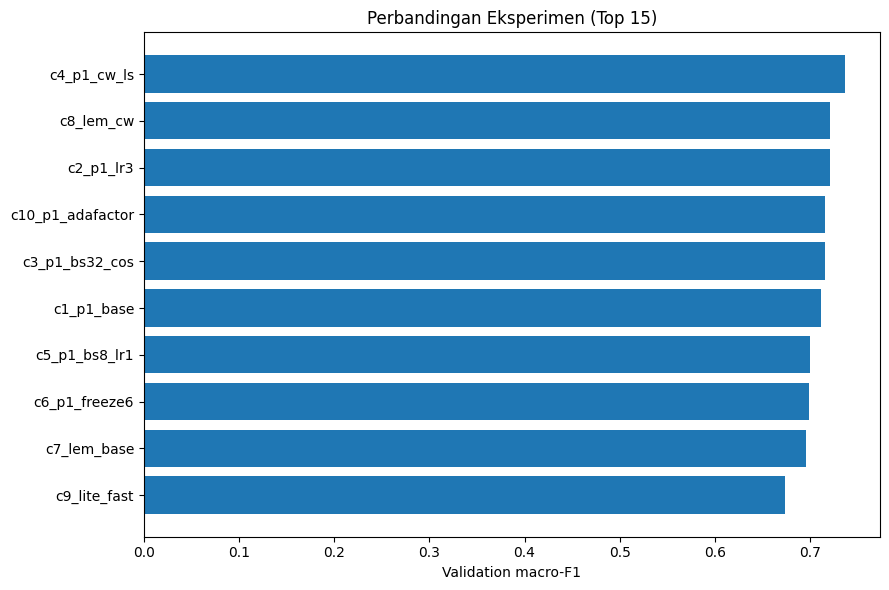

In [26]:

import matplotlib.pyplot as plt

if len(res_df) == 0:
    print('Tidak ada hasil eksperimen untuk divisualisasikan.')
else:
    top = res_df.head(15)[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top['name'], top['val_macro_f1'])
    plt.xlabel('Validation macro-F1')
    plt.title('Perbandingan Eksperimen (Top 15)')
    plt.tight_layout()
    plt.show()


## 9. Simpan model & hasil

In [27]:
OUT = '/kaggle/working/best_absa_indobert_v3_audited'
os.makedirs(OUT, exist_ok=True)

torch.save(bm.state_dict(), os.path.join(OUT, 'model_state.pt'))
bt.save_pretrained(OUT)

payload = {
    'model_name': bc['model_name'],
    'dataset_version': DATASET_VERSION,
    'split_version': SPLIT_VERSION,
    'train_path': str(train_path),
    'validation_path': str(val_path),
    'test_path': str(test_path),
    'split_manifest': split_manifest,
    'aspects': ASPECTS,
    'label2id': LABEL2ID,
    'id2label': ID2LABEL,
    'max_len': bc['max_len'],
    'best_cfg': dict(bc),
    'class_weight_mode': CLASS_WEIGHT_MODE,
    'class_weight_max': CLASS_WEIGHT_MAX,
    'class_weight_min': CLASS_WEIGHT_MIN,
    'val_macro_f1': float(best['vf1']),
    'test': tr,
    'train_rows': int(len(train_df)),
    'validation_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'no_aspect_audit': no_aspect_summary,
}
with open(os.path.join(OUT, 'config.json'), 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

res_df.to_csv(os.path.join(OUT, 'experiment_results.csv'), index=False)
if 'test_reports' in globals():
    with open(os.path.join(OUT, 'test_classification_reports.json'), 'w', encoding='utf-8') as f:
        json.dump(test_reports, f, indent=2, ensure_ascii=False)
if 'test_confusion_matrices' in globals():
    with open(os.path.join(OUT, 'test_confusion_matrices.json'), 'w', encoding='utf-8') as f:
        json.dump(test_confusion_matrices, f, indent=2, ensure_ascii=False)
if len(no_aspect_df) > 0 and 'noP' in globals():
    no_aspect_pred = no_aspect_df.copy()
    for i, aspect in enumerate(ASPECTS):
        no_aspect_pred[f'pred_{aspect}'] = [ID2LABEL[int(x)] for x in noP[:, i]]
    no_aspect_pred.to_csv(os.path.join(OUT, 'no_aspect_predictions.csv'), index=False)

print('Saved ->', OUT)
print(os.listdir(OUT))


Saved -> /kaggle/working/best_absa_indobert
['model_state.pt', 'experiment_results.csv', 'vocab.txt', 'special_tokens_map.json', 'test_classification_reports.json', 'no_aspect_predictions.csv', 'config.json', 'tokenizer.json', 'test_confusion_matrices.json', 'tokenizer_config.json']


## Catatan akhir
- **Mulai dengan `SEARCH_MODE='curated'`** untuk target cepat di Kaggle T4.
- Split train/validation/test sekarang dibaca dari path Kaggle eksplisit (`absa-santika-split`) agar eksperimen reproducible dan tidak salah mengambil file bernama sama.
- `no_aspect.csv` tidak dipakai sebagai data training utama; file ini dipakai sebagai **audit hallucination / false aspect rate**, yaitu apakah model memprediksi aspek pada review yang seharusnya tidak memiliki aspek.
- Class weight memakai **sqrt inverse-frequency + clipping** agar imbalance tetap tertangani tanpa membuat kelas minoritas yang sangat kecil menjadi terlalu dominan.
- Evaluasi akhir mencakup macro-F1, weighted-F1, non-None macro-F1, aspect-detection F1, false-aspect rate, classification report, dan confusion matrix per aspek.
- Simpan hasil terbaik di `/kaggle/working/best_absa_indobert`, lalu download folder output tersebut untuk dokumentasi eksperimen skripsi.
